# Learn Data Analysis with Rare Disease Genes

Welcome! In this notebook, you'll learn how to explore and analyze real scientific data using Python.

## What You'll Learn
- How to load and explore CSV files with pandas
- How to filter, sort, and summarize data
- How to merge two datasets together

## The Datasets
We have two datasets:
1. **Rare Disease Genes** - Links rare diseases to the genes that cause them
2. **Ensembl Gene Annotations** - Information about all human genes (location, type, etc.)

## Prerequisites
- Basic Python knowledge (variables, lists, functions)
- No prior pandas experience needed!

Let's get started!

---
## Part 1: Setting Up

First, we need to import **pandas**, a Python library for working with data tables.

Think of pandas like a super-powered Excel that you control with code!

In [ ]:
# Import pandas and give it a short nickname 'pd'
import pandas as pd

print("Pandas imported successfully!")
print(f"Pandas version: {pd.__version__}")

Pandas imported successfully!
Pandas version: 2.2.2


---
## Part 2: Loading the Rare Disease Dataset

Let's load our first dataset - the rare disease genes.

A **CSV file** (Comma-Separated Values) is a simple text file where each line is a row, and commas separate the columns.

In [ ]:
# Load the rare disease genes dataset
# Using GitHub raw URL so it works in Colab
diseases = pd.read_csv('https://raw.githubusercontent.com/narayananr/rare_diseases/main/data/rare_gene_disease_dataset.csv') # This is the data set we're analysing.

# Show the first 5 rows
diseases.head()

,disease,gene,gene_name
0,Multiple epiphyseal dysplasia-macrocephaly-fac...,KIF7,kinesin family member 7
1,Brachydactyly-short stature-retinitis pigmento...,CWC27,CWC27 spliceosome associated cyclophilin
2,Aspartylglucosaminuria,AGA,aspartylglucosaminidase
3,Multiple sulfatase deficiency,SUMF1,sulfatase modifying factor 1
4,Beta-mannosidosis,MANBA,mannosidase beta


### Understanding the Data

Each row represents a link between a disease and a gene:
- **disease**: The name of a rare disease
- **gene**: The gene symbol (short name scientists use)
- **gene_name**: The full name of the gene

In [ ]:
# How big is our dataset?
print(f"Number of rows: {len(diseases)}") # len shows the number of rows
print(f"Number of columns: {len(diseases.columns)}") # len(x.columns) shows how many columns there are
print(f"\nColumn names: {list(diseases.columns)}") # And list shows us the columns themselves

Number of rows: 8374
Number of columns: 3

Column names: ['disease', 'gene', 'gene_name']


### 🎯 Exercise 1: Basic Exploration

Use the `.tail()` method to see the **last** 10 rows of the dataset.

*Hint: It works just like `.head()` but shows the end instead of the beginning.*

In [ ]:
# YOUR CODE HERE: Show the last 10 rows
diseases.tail(10) # Have to pass a parameter/value to obtain x number of rows

,disease,gene,gene_name
8364,SBDS-related severe neonatal spondylometaphyse...,SBDS,SBDS ribosome maturation factor
8365,F12-associated cold autoinflammatory syndrome,F12,coagulation factor XII
8366,Congenital neutropenia-combined immunodeficien...,MRTFA,myocardin related transcription factor A
8367,SAMD9L-associated autoinflammatory syndrome,SAMD9L,sterile alpha motif domain containing 9 like
8368,Familial hyperinflammatory lymphoproliferative...,NCKAP1L,NCK associated protein 1 like
8369,Early-onset autoimmunity-autoinflammation-immu...,SOCS1,suppressor of cytokine signaling 1
8370,Developmental delay-immunodeficiency-leukoence...,NFE2L2,NFE2 like bZIP transcription factor 2
8371,CADINS disease,CARD11,caspase recruitment domain family member 11
8372,NOCARH syndrome,CDC42,cell division cycle 42
8373,Hereditary persistence of fetal hemoglobin-int...,BCL11A,BCL11 transcription factor A


---
## Part 3: Exploring the Data

Let's answer some questions about rare diseases!

In [ ]:
# How many unique diseases are there?
unique_diseases = diseases['disease'].nunique() # Gets the number of unique diseases and assigns it to a variable
print(f"Number of unique diseases: {unique_diseases}") # Prints the number out by printing the same variable

Number of unique diseases: 4128


### 🎯 Try it yourself!

How many **unique genes** are in the dataset?

*Hint: Use `.nunique()` on the 'gene' column, just like we did for diseases.*

In [ ]:
# YOUR CODE HERE: Count unique genes
unique_genes = diseases['gene'].nunique()
print(f"Number of unique genes: {unique_genes}") # This is the same thing as above, but instead of calling the disease column, we're calling the gene column.
                                                 # Similarly we could potentially call the gene_name column

Number of unique genes: 4552


### Finding Specific Diseases

Let's search for diseases containing a specific word. We'll use **filtering** - one of the most powerful features of pandas!

In [ ]:
# Find all diseases with "diabetes" in the name
# str.contains() searches for text, case=False ignores upper/lowercase

diabetes_diseases = diseases[diseases['disease'].str.contains('diabetes', case=False)]

# This basically searches for the key word diabetes.
# case=False basically means that we want every disease with the word diabetes, no matter the starting letter.
# If case=False wasn't there, it would only give us lower case starting ones.

print(f"Found {len(diabetes_diseases)} disease-gene links related to diabetes:\n") # This only gives us the number because of length
diabetes_diseases # Have to do this to get the result.

Found 21 disease-gene links related to diabetes:



,disease,gene,gene_name
2391,Pancreatic hypoplasia-diabetes-congenital hear...,GATA6,GATA binding protein 6
3755,Myopathy and diabetes mellitus,MT-TE,mitochondrially encoded tRNA-Glu (GAA/G)
4504,Primary microcephaly-epilepsy-permanent neonat...,IER3IP1,immediate early response 3 interacting protein 1
4505,Primary microcephaly-epilepsy-permanent neonat...,YIPF5,Yip1 domain family member 5
4802,Primary microcephaly-mild intellectual disabil...,PPP1R15B,protein phosphatase 1 regulatory subunit 15B
4803,Primary microcephaly-mild intellectual disabil...,TRMT10A,tRNA methyltransferase 10A
4920,Intrauterine growth restriction-short stature-...,CDKN1C,cyclin dependent kinase inhibitor 1C
5105,Juvenile-onset diabetes mellitus-central and p...,DNAJC3,DnaJ heat shock protein family (Hsp40) member C3
5614,Permanent neonatal diabetes mellitus-pancreati...,PTF1A,pancreas associated transcription factor 1a
5720,Neonatal diabetes-congenital hypothyroidism-co...,GLIS3,GLIS family zinc finger 3


### 🎯 Exercise 2: Search for Diseases

Try searching for diseases using different keywords! Here are some suggestions:

**By organ/system:**
| Keyword | What it finds |
|---------|---------------|
| `kidney` or `renal` | Kidney diseases |
| `liver` or `hepatic` | Liver conditions |
| `eye` or `retinal` | Vision disorders |
| `brain` or `neuro` | Neurological conditions |
| `muscle` or `muscular` | Muscle disorders |
| `lung` or `pulmonary` | Respiratory diseases |

**By condition type:**
| Keyword | What it finds |
|---------|---------------|
| `cancer` or `tumor` | Various cancers |
| `dystrophy` | Muscular dystrophies |
| `epilepsy` | Seizure disorders |
| `anemia` | Blood disorders |
| `deafness` | Hearing loss |
| `ataxia` | Movement disorders |

**Try it:** Pick a keyword and search for it!

In [ ]:
# YOUR CODE HERE: Search for diseases using a keyword from the table above
# Basically the same as the above code.
# Example pattern: diseases[diseases['disease'].str.contains('your_keyword', case=False)]
epilepsy_diseases = diseases[diseases['disease'].str.contains('epilepsy', case=False)]

print(f"Found {len(epilepsy_diseases)} disease-gene links related to epilepsy:\n")
epilepsy_diseases

Found 126 disease-gene links related to epilepsy:



,disease,gene,gene_name
39,Hot water reflex epilepsy,SLC1A1,solute carrier family 1 member 1
106,Hyperekplexia-epilepsy syndrome,ARHGEF9,Cdc42 guanine nucleotide exchange factor 9
108,Juvenile myoclonic epilepsy,CILK1,ciliogenesis associated kinase 1
109,Juvenile myoclonic epilepsy,CACNB4,calcium voltage-gated channel auxiliary subuni...
110,Juvenile myoclonic epilepsy,GABRA1,gamma-aminobutyric acid type A receptor subuni...
...,...,...,...
7689,PCDH19 clustering epilepsy,PCDH19,protocadherin 19
7896,Epilepsy with auditory features,RELN,reelin
7897,Epilepsy with auditory features,LGI1,leucine rich glioma inactivated 1
7898,Epilepsy with auditory features,MICAL1,"microtubule associated monooxygenase, calponin..."


---
## Part 4: Which Genes Are Most Important?

Some genes are linked to many diseases. Let's find out which ones!

In [ ]:
# Count how many diseases each gene is linked to
# .value_counts in this case basically shows us how many diseases are caused by each gene.
gene_counts = diseases['gene'].value_counts()

# Show the top 10 most common genes
# By printing this, we get the top ten genes which cause the most diseases.
print("Top 10 genes linked to the most diseases:\n")
gene_counts.head(10)

Top 10 genes linked to the most diseases:



,count
gene,
HBB,29
TP53,22
LMNA,21
KIT,19
COL2A1,18
FGFR1,17
PIK3CA,15
HLA-DRB1,14
PTEN,14


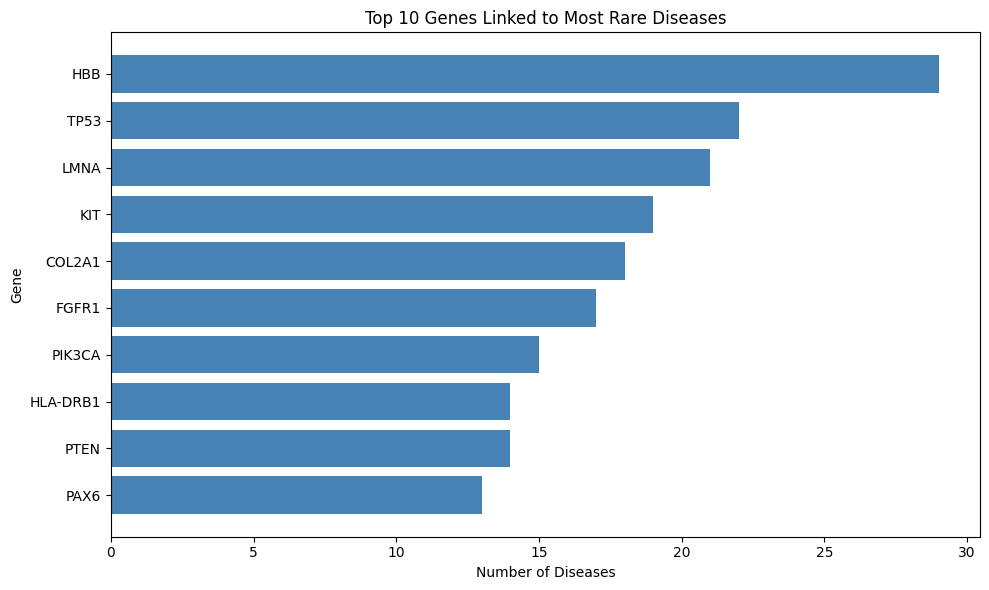

In [ ]:
# Let's visualize this with a bar chart!
import matplotlib.pyplot as plt # Do this to get a bar chart

top_genes = gene_counts.head(10)

# This just designs the graph
plt.figure(figsize=(10, 6))
plt.barh(top_genes.index, top_genes.values, color='steelblue')
plt.xlabel('Number of Diseases')
plt.ylabel('Gene')
plt.title('Top 10 Genes Linked to Most Rare Diseases')
plt.gca().invert_yaxis()  # Put the highest at the top
plt.tight_layout()
plt.show()

### 🎯 Exercise 3: Most Complex Diseases

Which diseases are linked to the most genes? Find the top 10.

*Hint: Use `value_counts()` on the 'disease' column instead of 'gene'.*

In [ ]:
# YOUR CODE HERE: Find diseases linked to the most genes
# .value_counts in this case basically shows us how many genes are linked to each disease.
disease_counts = diseases['disease'].value_counts()

# Show the top 10 most complex diseases
print("Top 10 diseases linked to the most genes:\n")
disease_counts.head(10)


Top 10 diseases linked to the most genes:



,count
disease,
Non-specific syndromic intellectual disability,114
Retinitis pigmentosa,88
Rare autosomal recessive non-syndromic sensorineural deafness type DFNB,74
Autosomal recessive non-syndromic intellectual disability,54
Non-specific early-onset epileptic encephalopathy,54
Familial isolated dilated cardiomyopathy,53
Primary ciliary dyskinesia,53
Rare autosomal dominant non-syndromic sensorineural deafness type DFNA,50
Autosomal dominant non-syndromic intellectual disability,43


---
## Part 5: Loading the Ensembl Gene Dataset

Now let's load our second dataset - information about all human genes.

In [ ]:
# Load the Ensembl gene annotations
genes = pd.read_csv('https://raw.githubusercontent.com/narayananr/rare_diseases/main/data/ensembl_genes.csv') # Another data set with different columns

# Everything after this is the same as the previous data set in terms of execution, just different columns and values.

# Show the first few rows
genes.head()

,ensembl_gene_id,gene_name,chromosome,start,end,strand,biotype,description
0,ENSG00000210049,MT-TF,MT,577,647,1,Mt_tRNA,mitochondrially encoded tRNA-Phe (UUU/C) [Sour...
1,ENSG00000211459,MT-RNR1,MT,648,1601,1,Mt_rRNA,mitochondrially encoded 12S rRNA [Source:HGNC ...
2,ENSG00000210077,MT-TV,MT,1602,1670,1,Mt_tRNA,mitochondrially encoded tRNA-Val (GUN) [Source...
3,ENSG00000210082,MT-RNR2,MT,1671,3229,1,Mt_rRNA,mitochondrially encoded 16S rRNA [Source:HGNC ...
4,ENSG00000209082,MT-TL1,MT,3230,3304,1,Mt_tRNA,mitochondrially encoded tRNA-Leu (UUA/G) 1 [So...


In [ ]:
# What columns do we have?
print("Columns in the genes dataset:")
for col in genes.columns:
    print(f"  - {col}")

print(f"\nTotal genes: {len(genes)}")

Columns in the genes dataset:
  - ensembl_gene_id
  - gene_name
  - chromosome
  - start
  - end
  - strand
  - biotype
  - description

Total genes: 78691


### Understanding Gene Annotations

| Column | What it means |
|--------|---------------|
| `ensembl_gene_id` | Unique ID (like a barcode for the gene) |
| `gene_name` | Gene symbol (short name) |
| `chromosome` | Which chromosome the gene is on (1-22, X, Y, MT) |
| `start` / `end` | Position on the chromosome (in base pairs) |
| `strand` | Direction the gene is read (1 = forward, -1 = reverse) |
| `biotype` | Type of gene (protein_coding, lncRNA, etc.) |

In [ ]:
# What types of genes are there?
print("Gene types (biotypes):\n")
genes['biotype'].value_counts().head(10)

Gene types (biotypes):



,count
biotype,
lncRNA,34880
protein_coding,20097
processed_pseudogene,9487
misc_RNA,2207
unprocessed_pseudogene,1949
snRNA,1901
miRNA,1879
transcribed_unprocessed_pseudogene,1587
transcribed_processed_pseudogene,1149


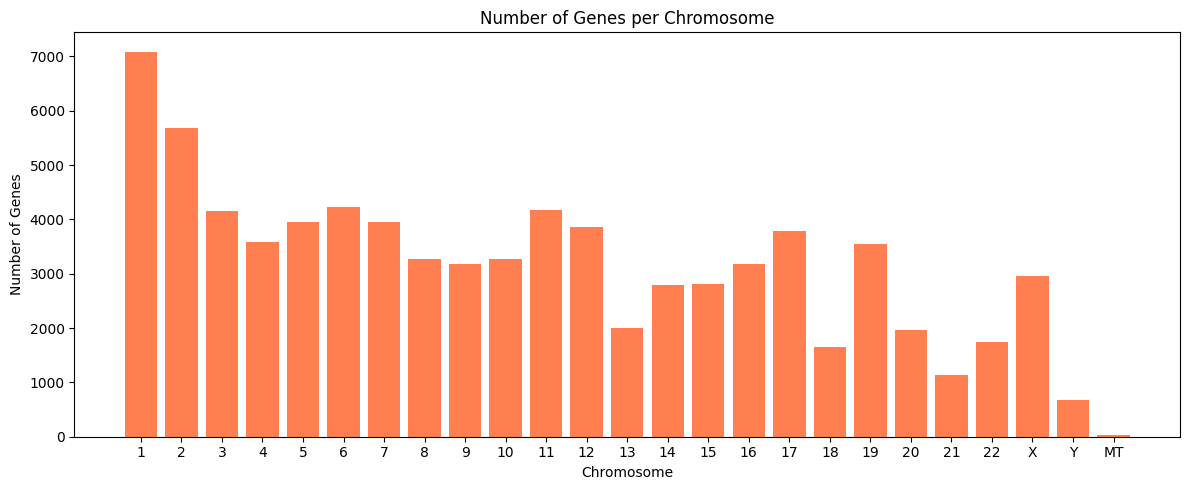

In [ ]:
# How many genes on each chromosome?
chromosome_counts = genes['chromosome'].value_counts()

# Sort chromosomes in logical order
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
chromosome_counts = chromosome_counts.reindex(chrom_order)

plt.figure(figsize=(12, 5))
plt.bar(chromosome_counts.index, chromosome_counts.values, color='coral')
plt.xlabel('Chromosome')
plt.ylabel('Number of Genes')
plt.title('Number of Genes per Chromosome')
plt.tight_layout()
plt.show()

### 🎯 Exercise 4: Protein-Coding Genes

Filter the genes dataset to show only **protein_coding** genes. How many are there?

*Hint: Use `genes[genes['biotype'] == 'protein_coding']`*

In [ ]:
# YOUR CODE HERE: Filter to protein-coding genes only
gene_type = genes[genes['biotype'].str.contains('protein_coding', case=False)]
print(f"Found {len(gene_type)} genes related to protein coding:\n")
gene_type

Found 20097 genes related to protein coding:



,ensembl_gene_id,gene_name,chromosome,start,end,strand,biotype,description
5,ENSG00000198888,MT-ND1,MT,3307,4262,1,protein_coding,mitochondrially encoded NADH:ubiquinone oxidor...
9,ENSG00000198763,MT-ND2,MT,4470,5511,1,protein_coding,mitochondrially encoded NADH:ubiquinone oxidor...
15,ENSG00000198804,MT-CO1,MT,5904,7445,1,protein_coding,mitochondrially encoded cytochrome c oxidase I...
18,ENSG00000198712,MT-CO2,MT,7586,8269,1,protein_coding,mitochondrially encoded cytochrome c oxidase I...
20,ENSG00000228253,MT-ATP8,MT,8366,8572,1,protein_coding,mitochondrially encoded ATP synthase membrane ...
...,...,...,...,...,...,...,...,...
78686,ENSG00000168710,AHCYL1,1,109984765,110023742,1,protein_coding,adenosylhomocysteinase like 1 [Source:HGNC Sym...
78687,ENSG00000081692,JMJD4,1,227730412,227735411,-1,protein_coding,jumonji domain containing 4 [Source:HGNC Symbo...
78688,ENSG00000157873,TNFRSF14,1,2554244,2565382,1,protein_coding,TNF receptor superfamily member 14 [Source:HGN...
78689,ENSG00000132676,DAP3,1,155687833,155739014,1,protein_coding,death associated protein 3 [Source:HGNC Symbol...


---
## Part 6: Learning to Merge with Simple Examples

Before we merge our real datasets, let's learn how merging works with small, simple examples.

**Merging** combines two tables based on a common column (like a "key").

In [ ]:
# Create two simple dataframes to practice merging

# Table 1: Students and their favorite subject
movies = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol', 'David'],
    'subject': ['Math', 'Science', 'Art', 'Math']
})

# Table 2: Subjects and their teachers
ratings = pd.DataFrame({
    'subject': ['Math', 'Science', 'Music'],
    'teacher': ['Mr. Smith', 'Ms. Johnson', 'Mr. Brown']
})

print("Students table:")
print(movies)
print("\nTeachers table:")
print(ratings)

Students table:
  student  subject
0   Alice     Math
1     Bob  Science
2   Carol      Art
3   David     Math

Teachers table:
   subject      teacher
0     Math    Mr. Smith
1  Science  Ms. Johnson
2    Music    Mr. Brown


### Inner Merge (default)

An **inner merge** keeps only rows where the key exists in **BOTH** tables.

- Carol likes Art, but there's no Art teacher → Carol is dropped
- Music has a teacher, but no student likes it → Music is dropped

In [ ]:
# Inner merge: only matching rows
inner_result = movies.merge(ratings, on='subject', how='inner')
print("INNER merge result:")
print(inner_result)
print(f"\n→ Only {len(inner_result)} rows where subject matches in both tables")

INNER merge result:
  student  subject      teacher
0   Alice     Math    Mr. Smith
1     Bob  Science  Ms. Johnson
2   David     Math    Mr. Smith

→ Only 3 rows where subject matches in both tables


### Left Merge

A **left merge** keeps ALL rows from the **left** (first) table, even if there's no match.

- All students are kept
- Carol has no matching teacher → teacher is NaN (missing)

In [ ]:
# Left merge: keep all rows from left table
left_result = movies.merge(ratings, on='subject', how='left')
print("LEFT merge result:")
print(left_result)
print(f"\n→ All {len(left_result)} students kept, NaN where no teacher match")

LEFT merge result:
  student  subject      teacher
0   Alice     Math    Mr. Smith
1     Bob  Science  Ms. Johnson
2   Carol      Art          NaN
3   David     Math    Mr. Smith

→ All 4 students kept, NaN where no teacher match


### Right Merge

A **right merge** keeps ALL rows from the **right** (second) table.

- All teachers/subjects are kept
- Music has no student → student is NaN

In [ ]:
# Right merge: keep all rows from right table
right_result = movies.merge(ratings, on='subject', how='right')
print("RIGHT merge result:")
print(right_result)
print(f"\n→ All {len(right_result)} subjects kept, NaN where no student match")

RIGHT merge result:
  student  subject      teacher
0   Alice     Math    Mr. Smith
1   David     Math    Mr. Smith
2     Bob  Science  Ms. Johnson
3     NaN    Music    Mr. Brown

→ All 4 subjects kept, NaN where no student match


### Outer Merge (Full)

An **outer merge** keeps ALL rows from BOTH tables.

- All students kept
- All teachers kept
- NaN where there's no match on either side

In [ ]:
# Outer merge: keep all rows from both tables
outer_result = movies.merge(ratings, on='subject', how='outer')
print("OUTER merge result:")
print(outer_result)
print(f"\n→ All {len(outer_result)} rows from both tables, NaN where no match")

OUTER merge result:
  student  subject      teacher
0   Carol      Art          NaN
1   Alice     Math    Mr. Smith
2   David     Math    Mr. Smith
3     NaN    Music    Mr. Brown
4     Bob  Science  Ms. Johnson

→ All 5 rows from both tables, NaN where no match


### Summary: Types of Merges

| Type | Keeps | Use when... |
|------|-------|-------------|
| `inner` | Only matching rows | You only want complete data |
| `left` | All from left table | You want to add info to your main table |
| `right` | All from right table | You want to add info to the second table |
| `outer` | All from both | You want everything, even incomplete |

### 🎯 Exercise 5: Practice Merging

Create two small dataframes and practice merging them!

In [ ]:
# 1. Create DataFrames
movies = pd.DataFrame({
    'movie': ['Inception', 'Avatar', 'Titanic'], # Column is 'movie'
    'year': [2010, 2009, 1997]
})

ratings = pd.DataFrame({
    'movie': ['Inception', 'Avatar', 'Frozen'],   # Column is 'movie'
    'rating': [8.8, 7.9, 7.4]
})

# 2. Corrected Merge Code (using 'movie' instead of 'movies')
# Inner merge: only matching rows
inner_result = movies.merge(ratings, on='movie', how='inner')
print("INNER merge result:")
print(inner_result)

# Left merge: keep all rows from left table
left_result = movies.merge(ratings, on='movie', how='left')
print("\nLEFT merge result:")
print(left_result)

# Right merge: keep all rows from right table
right_result = movies.merge(ratings, on='movie', how='right')
print("\nRIGHT merge result:")
print(right_result)

# Outer merge: keep all rows from both tables
outer_result = movies.merge(ratings, on='movie', how='outer')
print("\nOUTER merge result:")
print(outer_result)


INNER merge result:
       movie  year  rating
0  Inception  2010     8.8
1     Avatar  2009     7.9

LEFT merge result:
       movie  year  rating
0  Inception  2010     8.8
1     Avatar  2009     7.9
2    Titanic  1997     NaN

RIGHT merge result:
       movie    year  rating
0  Inception  2010.0     8.8
1     Avatar  2009.0     7.9
2     Frozen     NaN     7.4

OUTER merge result:
       movie    year  rating
0     Avatar  2009.0     7.9
1     Frozen     NaN     7.4
2  Inception  2010.0     8.8
3    Titanic  1997.0     NaN


---
## Part 7: 🎯 Final Challenge - Merge the Real Datasets!

Now it's YOUR turn! Use what you learned to merge the rare disease and gene datasets.

**Goal:** Find out which chromosomes have the most rare disease genes.

**Hints:**
- The `diseases` dataframe has a column called `gene`
- The `genes` dataframe has a column called `gene_name`
- These columns contain the same type of data (gene symbols)
- Use `left_on` and `right_on` when column names are different
- Think about which merge type makes sense here

In [ ]:
# Step 1: Check the column names in each dataset
print("Diseases columns:", list(diseases.columns))
print("Genes columns:", list(genes.columns))

Diseases columns: ['disease', 'gene', 'gene_name']
Genes columns: ['ensembl_gene_id', 'gene_name', 'chromosome', 'start', 'end', 'strand', 'biotype', 'description']


In [ ]:
# Step 2: YOUR CODE HERE - Merge the datasets!
# Merge diseases with genes to add chromosome information

# merged = diseases.merge(???)

merged = diseases.merge(
    genes,
    left_on='gene',
    right_on='gene_name',
    how='left'
)

# Optional: Display the first few rows and check column types
print(merged.head())
print(merged.info())



                                             disease   gene  \
0  Multiple epiphyseal dysplasia-macrocephaly-fac...   KIF7   
1  Brachydactyly-short stature-retinitis pigmento...  CWC27   
2                             Aspartylglucosaminuria    AGA   
3                      Multiple sulfatase deficiency  SUMF1   
4                                  Beta-mannosidosis  MANBA   

                                gene_name_x  ensembl_gene_id gene_name_y  \
0                   kinesin family member 7  ENSG00000166813        KIF7   
1  CWC27 spliceosome associated cyclophilin  ENSG00000153015       CWC27   
2                   aspartylglucosaminidase  ENSG00000038002         AGA   
3              sulfatase modifying factor 1  ENSG00000144455       SUMF1   
4                          mannosidase beta  ENSG00000109323       MANBA   

  chromosome        start          end  strand         biotype  \
0         15   89608789.0   89663098.0    -1.0  protein_coding   
1          5   64766368.0   6510


<details>
<summary>💡 Click here for the solution</summary>

```python
merged = diseases.merge(
    genes,
    left_on='gene',
    right_on='gene_name',
    how='left'
)
```

We use `left` merge because:
- We want to keep ALL disease-gene links
- We're adding chromosome info from the genes table
- Some genes might not be in Ensembl (rare, but possible)

</details>

In [ ]:
# Step 3: After merging, analyze your results!
# Uncomment and run after you've created 'merged'

# print(f"Merged dataset has {len(merged)} rows")
# print(f"\nColumns: {list(merged.columns)}")
# merged.head()

merged = diseases.merge(genes, left_on='gene', right_on='gene_name', how='left')

# Optional: View the first few rows to confirm merge
print(merged.head())


                                             disease   gene  \
0  Multiple epiphyseal dysplasia-macrocephaly-fac...   KIF7   
1  Brachydactyly-short stature-retinitis pigmento...  CWC27   
2                             Aspartylglucosaminuria    AGA   
3                      Multiple sulfatase deficiency  SUMF1   
4                                  Beta-mannosidosis  MANBA   

                                gene_name_x  ensembl_gene_id gene_name_y  \
0                   kinesin family member 7  ENSG00000166813        KIF7   
1  CWC27 spliceosome associated cyclophilin  ENSG00000153015       CWC27   
2                   aspartylglucosaminidase  ENSG00000038002         AGA   
3              sulfatase modifying factor 1  ENSG00000144455       SUMF1   
4                          mannosidase beta  ENSG00000109323       MANBA   

  chromosome        start          end  strand         biotype  \
0         15   89608789.0   89663098.0    -1.0  protein_coding   
1          5   64766368.0   6510

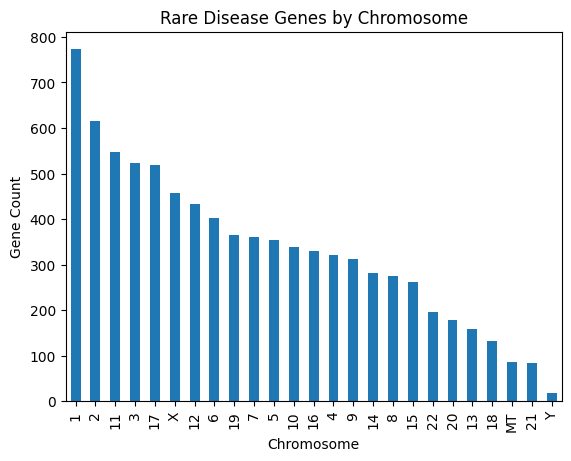

In [ ]:
# Step 4: YOUR CODE HERE - Create a visualization!
# Which chromosomes have the most rare disease genes?
#
# Hint: Use merged['chromosome'].value_counts() and plt.bar()

import matplotlib.pyplot as plt

# Use left_on/right_on since the gene identifier columns have different names
merged = diseases.merge(genes, left_on='gene', right_on='gene_name', how='left')

# Step 4: Create a visualization!
# Count occurrences of each chromosome, sort, and plot
chromosome_counts = merged['chromosome'].value_counts()
chromosome_counts.plot(kind='bar', title='Rare Disease Genes by Chromosome')
plt.xlabel('Chromosome')
plt.ylabel('Gene Count')
plt.show()

---
## 🎯 Final Exercise: Your Own Analysis

Using the merged dataset, answer ONE of these questions:

1. **Which chromosome has the most diseases related to "cancer"?**
   - Filter merged for diseases containing 'cancer'
   - Count by chromosome

2. **What is the average gene length for rare disease genes vs all genes?**
   - Gene length = `end` - `start`
   - Compare averages

3. **Find all diseases on chromosome X**
   - Filter merged where chromosome == 'X'
   - Show unique diseases

Write your code below!

In [ ]:
# EXAMPLE: Find all diseases on chromosome X
x_diseases = merged[merged['chromosome'] == 'X']
print(f"Found {len(x_diseases)} disease-gene links on chromosome X")
print(f"Unique diseases: {x_diseases['disease'].nunique()}")
print("\nSample diseases on X chromosome:")
x_diseases['disease'].drop_duplicates().head(10)

Found 457 disease-gene links on chromosome X
Unique diseases: 367

Sample diseases on X chromosome:


,disease
22,Paroxysmal nocturnal hemoglobinuria
37,Recessive X-linked ichthyosis
43,Cystic fibrosis
100,"X-linked intellectual disability, Najm type"
102,"X-linked dominant chondrodysplasia, Chassaing-..."
103,"X-linked intellectual disability, Van Esch type"
104,"X-linked intellectual disability, Nascimento type"
105,Fabry disease
106,Hyperekplexia-epilepsy syndrome
107,Rett syndrome


In [ ]:
# Goal: Which chromosomes have the most rare disease genes?
# Count by chromosome
chromosome_counts = merged['chromosome'].value_counts()
print("\nRare disease genes per chromosome:\n", chromosome_counts)

# Answer ONE question: Which chromosome has the most diseases related to cancer?
# Filter for 'cancer' (case-insensitive)
cancer_diseases = merged[merged['disease'].str.contains('cancer', case=False, na=False)]
top_cancer_chrom = cancer_diseases['chromosome'].value_counts().idxmax()
print(f"\nChromosome with most cancer-related diseases: {top_cancer_chrom}")



Rare disease genes per chromosome:
 chromosome
1     773
2     615
11    547
3     523
17    518
X     457
12    433
6     402
19    364
7     360
5     353
10    339
16    330
4     322
9     312
14    281
8     275
15    262
22    197
20    179
13    159
18    133
MT     86
21     83
Y      18
Name: count, dtype: int64

Chromosome with most cancer-related diseases: 17


---
## Part 8: More Exploration Examples

Here are more examples to help you explore the data!

### Example: Calculate Gene Length

Genes have different sizes. Let's calculate the length of each gene!

In [ ]:
# Calculate gene length (end position - start position)
genes['length'] = genes['end'] - genes['start']

# What's the average gene length?
print(f"Average gene length: {genes['length'].mean():,.0f} base pairs")
print(f"Shortest gene: {genes['length'].min():,} base pairs")
print(f"Longest gene: {genes['length'].max():,} base pairs")

# Find the longest gene
longest_gene = genes.loc[genes['length'].idxmax()]
print(f"\nThe longest gene is: {longest_gene['gene_name']}")
print(f"It's {longest_gene['length']:,} base pairs long!")

Average gene length: 31,493 base pairs
Shortest gene: 7 base pairs
Longest gene: 2,473,538 base pairs

The longest gene is: RBFOX1
It's 2,473,538 base pairs long!


### Example: Using groupby() for Summaries

`groupby()` lets you calculate statistics for each group in your data.

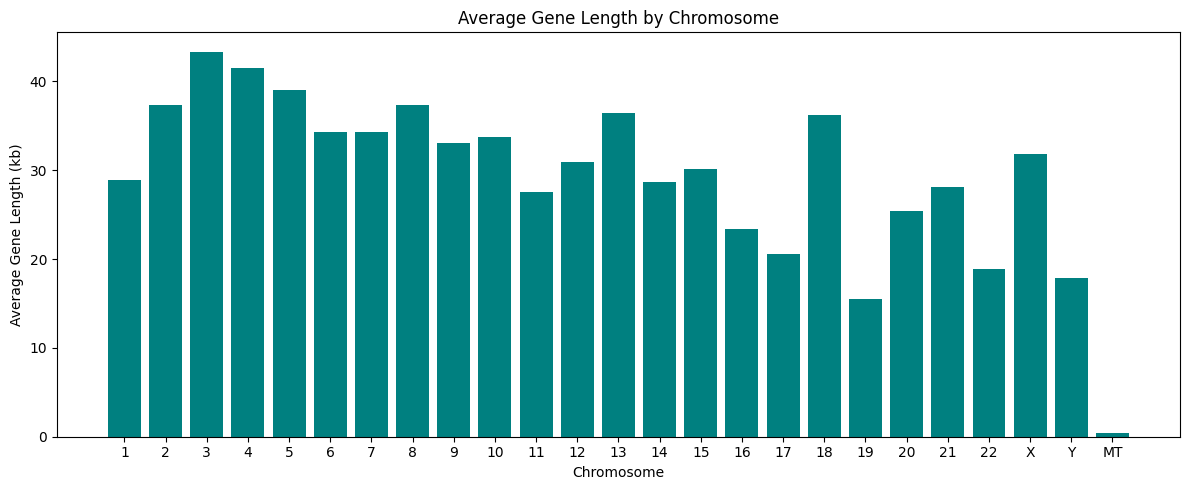

In [ ]:
# Average gene length by chromosome
avg_length_by_chrom = genes.groupby('chromosome')['length'].mean()

# Sort by chromosome order
chrom_order = [str(i) for i in range(1, 23)] + ['X', 'Y', 'MT']
avg_length_by_chrom = avg_length_by_chrom.reindex(chrom_order)

# Visualize it
plt.figure(figsize=(12, 5))
plt.bar(avg_length_by_chrom.index, avg_length_by_chrom.values / 1000, color='teal')
plt.xlabel('Chromosome')
plt.ylabel('Average Gene Length (kb)')
plt.title('Average Gene Length by Chromosome')
plt.tight_layout()
plt.show()

### Example: Finding Patterns in Disease Names

Let's explore what types of diseases are in our dataset by looking at common words.

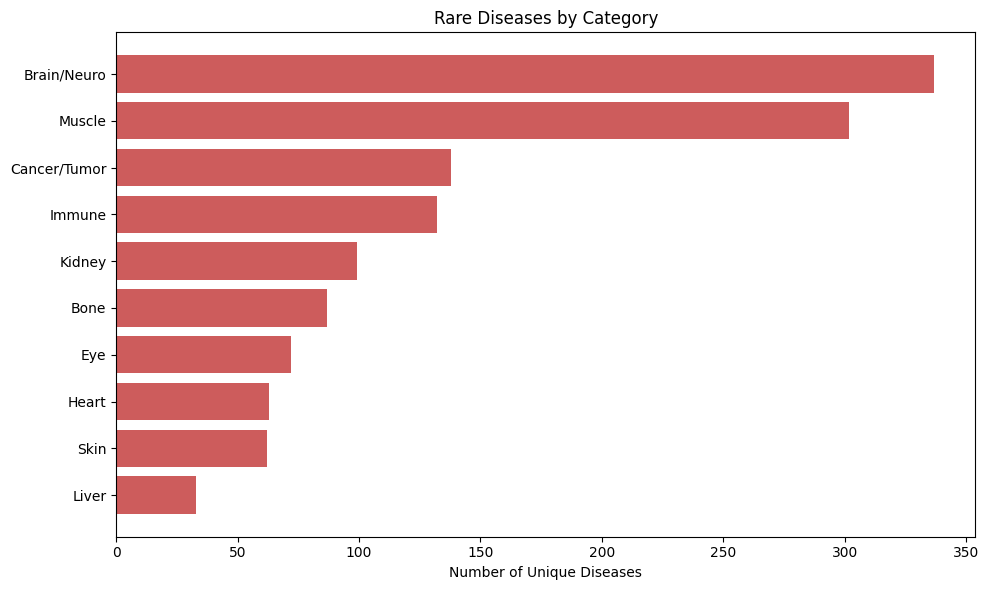

In [ ]:
# Count diseases by category (using keyword search)
categories = {
    'Cancer/Tumor': 'cancer|tumor|carcinoma|lymphoma|leukemia',
    'Heart': 'heart|cardiac|cardiomyopathy',
    'Brain/Neuro': 'brain|neuro|epilepsy|ataxia|neuropathy',
    'Eye': 'eye|retinal|blindness|optic|macular',
    'Muscle': 'muscle|muscular|myopathy|dystrophy',
    'Kidney': 'kidney|renal|nephro',
    'Liver': 'liver|hepatic',
    'Skin': 'skin|dermato|epidermolysis',
    'Bone': 'bone|osteo|skeletal',
    'Immune': 'immune|immunodeficiency'
}

# Count unique diseases in each category
category_counts = {}
for cat, pattern in categories.items():
    matches = diseases[diseases['disease'].str.contains(pattern, case=False)]
    category_counts[cat] = matches['disease'].nunique()

# Create a bar chart
cat_df = pd.Series(category_counts).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(cat_df.index, cat_df.values, color='indianred')
plt.xlabel('Number of Unique Diseases')
plt.title('Rare Diseases by Category')
plt.tight_layout()
plt.show()

---
## Part 9: Bonus Challenges 🏆

Try these challenges to test your skills!

### Challenge 1: Gene Detective 🔍

The gene **BRCA1** is famous for being linked to breast cancer.

**Task:** Find ALL diseases linked to BRCA1 in our dataset.

In [ ]:
# Challenge 1: Find all diseases linked to BRCA1
brca1_diseases = merged[merged['gene'] == 'BRCA1']['disease'].unique()
print(f"Diseases linked to BRCA1: {brca1_diseases}")



Diseases linked to BRCA1: ['Primary peritoneal carcinoma' 'Fanconi anemia'
 'Familial prostate cancer'
 'Hereditary breast and/or ovarian cancer syndrome'
 'Hereditary breast cancer' 'Familial pancreatic carcinoma'
 'Cholangiocarcinoma' 'Inflammatory breast cancer'
 'Breast implant-associated anaplastic large cell lymphoma']


### Challenge 2: Chromosome Comparison 📊

**Task:** Compare the number of rare disease genes on the **X chromosome** vs the **Y chromosome**.

Which has more? Why might that be? (Hint: Think about the size of each chromosome)

---
## Congratulations! 🎉

You've learned how to:
- ✅ Load CSV files with pandas
- ✅ Explore data with `.head()`, `.tail()`, `len()`
- ✅ Filter data with conditions
- ✅ Count and summarize with `.value_counts()`
- ✅ Create visualizations with matplotlib
- ✅ **Merge two datasets together!**

### What's Next?
- Try loading your own CSV files
- Explore more pandas functions: `.groupby()`, `.sort_values()`, `.describe()`
- Learn more visualization with seaborn or plotly

### Resources
- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Kaggle Learn: Pandas](https://www.kaggle.com/learn/pandas)
- [Python for Data Analysis (book)](https://wesmckinney.com/book/)